In [18]:
import pandas as pd
from IPython.core.pylabtools import activate_matplotlib

# Load the CSV file
file_path = 'content/distinct_buildings excel.csv'  # Adjust the file path if needed
data = pd.read_csv(file_path, delimiter=';')

# Check if 'location' column exists
if 'location' in data.columns:
    # Split the 'location' column into 'latitude' and 'longitude'
    data[['latitude', 'longitude']] = data['location'].str.split(',', expand=True)

    # Optionally, you can drop the original 'location' column
    data.drop(columns=['location'], inplace=True)
    data.drop(columns=['Column1'], inplace=True)
    data.rename(columns={
    'building': 'building_code'}, inplace=True)
    # Save the modified DataFrame to a new CSV file
    new_file_path = 'content/distinct_buildings_modified.csv'
    data.to_csv(new_file_path, index=False, sep=';')

    print("File processed and saved as:", new_file_path)
else:
    print("The 'location' column was not found in the CSV file.")

File processed and saved as: content/distinct_buildings_modified.csv


In [19]:
data

,building_code,latitude,longitude
0,ZI,52.23920253719435,6.856910817479597
1,CR,52.23816328226085,6.857637461359666
2,HT,52.23761533457211,6.860704629276648
3,RA,52.239394466454705,6.855659446986793
4,CU,52.2404747275504,6.856748790412035
5,SP,52.23967014713761,6.849788127854926
6,SC,52.24387520603568,6.850267866916351
7,NH,52.23808480549669,6.861725240099451
8,OH,52.23695706050182,6.861045395561615
9,HB,52.23872999804916,6.857130329481763


In [20]:
from sqlalchemy import create_engine
import pandas as pd

driver = 'postgresql'
username = 'dab_ds23241a_123'
dbname = username  # it is the same as the username
password = 'BdleaEuFH036h8hi'
server = 'bronto.ewi.utwente.nl'
port = '5432'
# Creating the connection pool for SQL
engine = create_engine(f'{driver}://{username}:{password}@{server}:{port}/{dbname}?client_encoding=utf8')

sql_query1 = 'SELECT * FROM timetables2.activities'
sql_query2 = 'SELECT * FROM timetables2.courses'

# Use pandas to execute the query and load results into a DataFrame
activities = pd.read_sql_query(sql_query1, engine)
courses = pd.read_sql_query(sql_query2,engine)

In [21]:
courses

,course_code,program_code,teacher_id,year,course_name
0,191100010,IO B,M7665471,2013,TRIZ - Fundamentals
1,191102010,ME M,M7665495,2013,Life-cycle Strategy
2,191102031,ME M,M7681343,2013,Product Design
3,191102041,ME M,M7643357,2013,Manufacturing Facility Design
4,191103131,WB B,M7683142,2013,Project R (Ontw v.e. consmproduct)
...,...,...,...,...,...
1357,201600165,IO B,M7640452,2016,Realisation of Products
1358,201600166,AM M,M7641013,2016,Introduction to Mathematical Analysis
1359,201600167,AM M,M7641013,2016,Introduction to Mathematical Analysis
1360,201600172,IBA B,M7643552,2016,Innovation & Entrepreneurship


In [22]:
activities = activities.merge(courses[['course_code', 'program_code']], on='course_code', how='left')


In [23]:
def extract_building(room_str):
    # Check if room_str is None
    if room_str is None:
        return None  # or return a default value or placeholder if preferred
    # If the room string starts with 'ZZ ', remove it
    elif room_str.startswith("ZZ "):
        room_str = room_str[3:]
    # Extract the building code (the first two characters)
    building_code = room_str[:2]
    return building_code


# Apply the function to the 'room' column to create a new 'building' column
activities['building_code'] = activities['room'].apply(extract_building)

In [24]:
activities

,course_code,activity_name,start_time,end_time,year,activity_description,activity_type,duration,date,room,program_code,building_code
0,191210750,1B System-on-chip-Design/HC01/01,08:45:00,12:30:00,2013,191210750 System-on-chip-Design,PRA,3.75,2013-11-11,ZI W3,EE M,ZI
1,191210750,1B System-on-chip-Design/HC01/01,08:45:00,12:30:00,2013,191210750 System-on-chip-Design,PRA,3.75,2013-11-11,ZI W4,EE M,ZI
2,191210750,1B System-on-chip-Design/HC05/01,08:45:00,12:30:00,2013,191210750 System-on-chip-Design,PRA,3.75,2013-11-18,ZI W3,EE M,ZI
3,191210750,1B System-on-chip-Design/HC05/01,08:45:00,12:30:00,2013,191210750 System-on-chip-Design,PRA,3.75,2013-11-18,ZI W4,EE M,ZI
4,191210750,1B System-on-chip-Design/HC02/01,13:45:00,17:30:00,2013,191210750 System-on-chip-Design,PRA,3.75,2013-11-11,ZI W3,EE M,ZI
...,...,...,...,...,...,...,...,...,...,...,...,...
56257,201600099,Statistics II/HC01/01,10:45:00,12:30:00,2016,Statistics II,HC,1.75,2016-09-07,HR C101,IBA B,HR
56258,201600099,Statistics II/TOETS01/01,08:45:00,11:45:00,2016,Statistics II,TOETS,3.00,2016-10-24,ZZ NH 115/T,IBA B,NH
56259,201600099,Statistics II/TOETS01/01,08:45:00,11:45:00,2016,Statistics II,TOETS,3.00,2016-10-24,ZZ NH 124/T,IBA B,NH
56260,201600099,Statistics II/TOETS02/01,08:45:00,11:45:00,2016,Statistics II,TOETS,3.00,2016-11-07,ZZ SC/T,IBA B,SC


In [25]:
activities = activities.merge(data, left_on='building_code', right_on='building_code', how='left')



In [26]:
activities

,course_code,activity_name,start_time,end_time,year,activity_description,activity_type,duration,date,room,program_code,building_code,latitude,longitude
0,191210750,1B System-on-chip-Design/HC01/01,08:45:00,12:30:00,2013,191210750 System-on-chip-Design,PRA,3.75,2013-11-11,ZI W3,EE M,ZI,52.23920253719435,6.856910817479597
1,191210750,1B System-on-chip-Design/HC01/01,08:45:00,12:30:00,2013,191210750 System-on-chip-Design,PRA,3.75,2013-11-11,ZI W4,EE M,ZI,52.23920253719435,6.856910817479597
2,191210750,1B System-on-chip-Design/HC05/01,08:45:00,12:30:00,2013,191210750 System-on-chip-Design,PRA,3.75,2013-11-18,ZI W3,EE M,ZI,52.23920253719435,6.856910817479597
3,191210750,1B System-on-chip-Design/HC05/01,08:45:00,12:30:00,2013,191210750 System-on-chip-Design,PRA,3.75,2013-11-18,ZI W4,EE M,ZI,52.23920253719435,6.856910817479597
4,191210750,1B System-on-chip-Design/HC02/01,13:45:00,17:30:00,2013,191210750 System-on-chip-Design,PRA,3.75,2013-11-11,ZI W3,EE M,ZI,52.23920253719435,6.856910817479597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56257,201600099,Statistics II/HC01/01,10:45:00,12:30:00,2016,Statistics II,HC,1.75,2016-09-07,HR C101,IBA B,HR,52.23762429639754,6.860899781564861
56258,201600099,Statistics II/TOETS01/01,08:45:00,11:45:00,2016,Statistics II,TOETS,3.00,2016-10-24,ZZ NH 115/T,IBA B,NH,52.23808480549669,6.861725240099451
56259,201600099,Statistics II/TOETS01/01,08:45:00,11:45:00,2016,Statistics II,TOETS,3.00,2016-10-24,ZZ NH 124/T,IBA B,NH,52.23808480549669,6.861725240099451
56260,201600099,Statistics II/TOETS02/01,08:45:00,11:45:00,2016,Statistics II,TOETS,3.00,2016-11-07,ZZ SC/T,IBA B,SC,52.24387520603568,6.850267866916351


In [27]:
# import math
# import pandas as pd
# from geopy.distance import geodesic
#
# # Assuming 'activities_df' is your DataFrame with the activities data
# # Make sure to load or define 'activities_df' here if it's not already loaded
#
# # First, sort the DataFrame to ensure activities are ordered correctly
# activities.sort_values(by=['course_code', 'program_code', 'year', 'date', 'start_time'], inplace=True)
#
# # Function to calculate distances
# def calculate_distances(row, next_row):
#     if pd.isna(row['latitude']) or pd.isna(row['longitude']) or pd.isna(next_row['latitude']) or pd.isna(next_row['longitude']):
#         return None  # Return None if any coordinates are NaN
#     # Check if the next activity meets the criteria to calculate distance
#     if (row['course_code'] == next_row['course_code'] and
#         row['program_code'] == next_row['program_code'] and
#         row['year'] == next_row['year'] and
#         row['date'] == next_row['date']):
#         # Calculate and return the distance
#         return geodesic((row['latitude'], row['longitude']), (next_row['latitude'], next_row['longitude'])).kilometers
#     # Return None or 0 if criteria are not met
#     return None
#
# # Initialize a list to store calculated distances
# distances = []
#
# # Iterate through the DataFrame
# for i in range(len(activities) - 1):
#     # Calculate distance to next activity if criteria are met
#
#     distance = calculate_distances(activities.iloc[i], activities.iloc[i + 1])
#     distances.append(distance)
#
# # Append None for the last activity of each set, as it has no next activity
# distances.append(None)
#
# # Assign calculated distances to the DataFrame
# activities['distance_to_next_activity_km'] = distances
#
# # Optionally, save the updated DataFrame to a new CSV file
# new_file_path = 'updated_activities_with_distances.csv'
# activities.to_csv(new_file_path, index=False, sep=';')
#
# print("Updated file processed and saved as:", new_file_path)

In [30]:
from geopy.distance import geodesic
# # First, sort the DataFrame to ensure activities are ordered correctly
activities.sort_values(by=['course_code', 'program_code', 'year', 'date', 'start_time'], inplace=True)

def calculate_distances(row, next_row):
    # Check if the next activity meets the criteria to calculate distance
    if pd.isna(row['latitude']) or pd.isna(row['longitude']) or pd.isna(next_row['latitude']) or pd.isna(next_row['longitude']):
        return None  # Return None if any coordinates are NaN
    if (row['course_code'] == next_row['course_code'] and
        row['program_code'] == next_row['program_code'] and
        row['year'] == next_row['year'] and
        row['date'] == next_row['date']):

        # Check if consecutive activities have the same description
        if row['activity_description'] == next_row['activity_description']:
            return None  # Set distance to None if descriptions match

        # Calculate and return the distance
        return geodesic((row['latitude'], row['longitude']),
                        (next_row['latitude'], next_row['longitude'])).kilometers
    # Return None if criteria for same course, program, year, and date are not met
    return None

# Initialize a list to store calculated distances
distances = []

# Iterate through the DataFrame
for i in range(len(activities) - 1):
    # Calculate distance to next activity if criteria are met
    distance = calculate_distances(activities.iloc[i], activities.iloc[i + 1])
    distances.append(distance)

# Append None for the last activity of each set, as it has no next activity
distances.append(None)

# Assign calculated distances to the DataFrame
activities['distance_to_next_activity_km'] = distances

In [34]:
# drop lat and longitude as they are redundant in the db
activities = activities.drop('latitude',axis=1)
activities = activities.drop('longitude',axis=1)

KeyError: "['latitude'] not found in axis"

In [ ]:
activities

In [35]:
from sqlalchemy import create_engine

driver = 'postgresql'
username = 'dab_ds23241a_123'
dbname = username  # it is the same as the username
password = 'BdleaEuFH036h8hi'
server = 'bronto.ewi.utwente.nl'
port = '5432'
# Creating the connection pool for SQL
engine = create_engine(f'{driver}://{username}:{password}@{server}:{port}/{dbname}?client_encoding=utf8')

# courses.to_sql('courses', con=engine, schema='timetables', if_exists='append', index=False, method='multi')
activities.to_sql('activities', con=engine, schema='timetables', if_exists='append', index=False, method='multi')



262

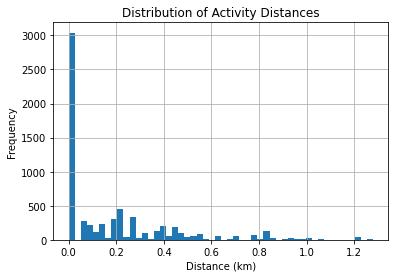

In [31]:
import matplotlib.pyplot as plt
activities['distance_to_next_activity_km'].dropna().hist(bins=50)
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')
plt.title('Distribution of Activity Distances')
plt.show()